In [1]:

# Import necessary libraries
import numpy as np
import pandas as pd
import pickle
from scipy.optimize import minimize_scalar
from collections import defaultdict
import time

# Load the precomputed omega values
print("Loading precomputed omega values...")
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values_1e6 = pickle.load(f)
print(f"Loaded omega values for N=10^6, shape: {omega_values_1e6.shape}")

with open('omega_values_N1e7.pkl', 'rb') as f:
 omega_values_1e7 = pickle.load(f)
print(f"Loaded omega values for N=10^7, shape: {omega_values_1e7.shape}")

# Load the N=10^7 detailed results
df_1e7 = pd.read_csv('N10^7_detailed_results.csv')
print("\nN=10^7 detailed results:")
print(df_1e7.head(10))


Loading precomputed omega values...
Loaded omega values for N=10^6, shape: (1000000,)
Loaded omega values for N=10^7, shape: (10000000,)

N=10^7 detailed results:
 Function N t_value peak_height r_value
0 Zeta 10000000 1.848485e+07 16.508561 0.780727
1 Zeta 10000000 1.232323e+07 10.284027 0.631713
2 Zeta 10000000 1.090909e+07 6.367052 -0.074793
3 Zeta 10000000 1.616162e+07 5.935386 1.437305
4 Zeta 10000000 1.191919e+07 5.878669 0.669312
5 Liouville 10000000 1.979798e+07 21.827989 1.924900
6 Liouville 10000000 1.787879e+07 17.305548 1.181383
7 Liouville 10000000 1.363636e+07 12.219003 1.787888
8 Liouville 10000000 1.929293e+07 9.473383 -0.345984
9 Liouville 10000000 1.212121e+07 7.941801 0.850410


In [2]:

# Extract the t_values for Liouville at N=10^7
liouville_1e7_data = df_1e7[df_1e7['Function'] == 'Liouville'].copy()
print("Liouville N=10^7 peak locations:")
print(liouville_1e7_data)
t_values_1e7 = liouville_1e7_data['t_value'].values
print(f"\nt_values for N=10^7: {t_values_1e7}")


Liouville N=10^7 peak locations:
 Function N t_value peak_height r_value
5 Liouville 10000000 1.979798e+07 21.827989 1.924900
6 Liouville 10000000 1.787879e+07 17.305548 1.181383
7 Liouville 10000000 1.363636e+07 12.219003 1.787888
8 Liouville 10000000 1.929293e+07 9.473383 -0.345984
9 Liouville 10000000 1.212121e+07 7.941801 0.850410

t_values for N=10^7: [19797979.7979798 17878787.87878788 13636363.63636364 19292929.29292929
 12121212.12121212]


In [3]:

# Define Kahan summation for complex numbers
def kahan_sum_complex(values):
 """Kahan compensated summation for complex array."""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for v in values:
 y = v - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

# Define Liouville function coefficients
def liouville_coefficients(N):
 """Generate Liouville function coefficients λ(n) = (-1)^Ω(n)"""
 omega_vals = omega_values_1e6[:N] if N <= 1000000 else omega_values_1e7[:N]
 return (-1.0) ** omega_vals

# Define Dirichlet polynomial evaluation with Kahan summation
def dirichlet_polynomial_kahan(a_n, t, N):
 """
 Evaluate D_F(t; N) = Σ_{n=1}^N a_n / n^{1/2 + it}
 using Kahan compensated summation.
 """
 n = np.arange(1, N + 1, dtype=np.float64)
 sqrt_n = np.sqrt(n)
 exponent = -t * np.log(n)
 
 # Compute exp(i * exponent) = cos(exponent) + i*sin(exponent)
 cos_exp = np.cos(exponent)
 sin_exp = np.sin(exponent)
 
 # Compute terms: a_n / sqrt(n) * exp(i * exponent)
 real_parts = (a_n / sqrt_n) * cos_exp
 imag_parts = (a_n / sqrt_n) * sin_exp
 
 # Use Kahan summation
 real_sum = kahan_sum_complex(real_parts).real
 imag_sum = kahan_sum_complex(imag_parts).real
 
 return real_sum + 1j * imag_sum

print("Defined Kahan summation and Dirichlet polynomial evaluation functions")


Defined Kahan summation and Dirichlet polynomial evaluation functions


In [4]:

# Step 1: Find top 5 highest-magnitude peaks for Liouville at N=10^6 in t ∈ [10^6, 2*10^6]
# Use two-phase approach: coarse grid search followed by local optimization

N_1e6 = 1000000
t_min_1e6 = 1e6
t_max_1e6 = 2e6

print(f"Phase 1: Coarse grid search for N=10^6 in t ∈ [{t_min_1e6:.0e}, {t_max_1e6:.0e}]")
print("Using fast vectorized evaluation for coarse grid...")

# Generate Liouville coefficients for N=10^6
a_n_1e6 = liouville_coefficients(N_1e6)

# Coarse grid: 10,000 points
n_coarse = 10000
t_coarse = np.linspace(t_min_1e6, t_max_1e6, n_coarse)

# Fast vectorized evaluation (without Kahan for speed)
def fast_dirichlet_eval(a_n, t_array, N):
 """Fast vectorized Dirichlet polynomial evaluation."""
 n = np.arange(1, N + 1, dtype=np.float64)
 sqrt_n = np.sqrt(n)
 
 magnitudes = []
 for t in t_array:
 exponent = -t * np.log(n)
 cos_exp = np.cos(exponent)
 sin_exp = np.sin(exponent)
 real_sum = np.sum((a_n / sqrt_n) * cos_exp)
 imag_sum = np.sum((a_n / sqrt_n) * sin_exp)
 magnitudes.append(np.sqrt(real_sum**2 + imag_sum**2))
 
 return np.array(magnitudes)

start_time = time.time()
magnitudes_coarse = fast_dirichlet_eval(a_n_1e6, t_coarse, N_1e6)
elapsed = time.time() - start_time
print(f"Coarse grid evaluated in {elapsed:.2f} seconds")

# Find top 10 candidates from coarse grid
top_indices = np.argsort(magnitudes_coarse)[-10:][::-1]
print(f"\nTop 10 candidates from coarse grid:")
for i, idx in enumerate(top_indices):
 print(f"{i+1}. t={t_coarse[idx]:.2f}, |D|={magnitudes_coarse[idx]:.4f}")


Phase 1: Coarse grid search for N=10^6 in t ∈ [1e+06, 2e+06]
Using fast vectorized evaluation for coarse grid...


Coarse grid evaluated in 436.32 seconds

Top 10 candidates from coarse grid:
1. t=1294029.40, |D|=54.9027
2. t=1199919.99, |D|=46.0677
3. t=1357935.79, |D|=43.0369
4. t=1911491.15, |D|=37.3370
5. t=1786778.68, |D|=35.6138
6. t=1196819.68, |D|=29.8976
7. t=1917491.75, |D|=29.2061
8. t=1491749.17, |D|=29.1231
9. t=1062906.29, |D|=29.1222
10. t=1330633.06, |D|=28.7908


In [5]:

# Phase 2: Local optimization with Kahan summation for top 10 candidates
print("Phase 2: Local optimization with Kahan summation for top 10 candidates...")

def objective_for_minimize(t, a_n, N):
 """Objective function for minimization (negative magnitude)."""
 D_val = dirichlet_polynomial_kahan(a_n, t, N)
 return -np.abs(D_val)

refined_peaks = []
for i, idx in enumerate(top_indices):
 t_candidate = t_coarse[idx]
 # Local optimization window: ±500 around candidate
 t_bounds = (max(t_min_1e6, t_candidate - 500), min(t_max_1e6, t_candidate + 500))
 
 print(f"Refining peak {i+1}/10 around t={t_candidate:.2f}...")
 result = minimize_scalar(
 objective_for_minimize,
 bounds=t_bounds,
 args=(a_n_1e6, N_1e6),
 method='bounded',
 options={'xatol': 1e-3}
 )
 
 t_refined = result.x
 D_refined = dirichlet_polynomial_kahan(a_n_1e6, t_refined, N_1e6)
 magnitude_refined = np.abs(D_refined)
 
 refined_peaks.append({
 't': t_refined,
 'magnitude': magnitude_refined,
 'D_value': D_refined
 })
 print(f" Refined: t={t_refined:.6f}, |D|={magnitude_refined:.6f}")

# Sort by magnitude and select top 5
refined_peaks.sort(key=lambda x: x['magnitude'], reverse=True)
top_5_peaks_1e6 = refined_peaks[:5]

print("\n" + "="*60)
print("TOP 5 HIGHEST-MAGNITUDE PEAKS AT N=10^6:")
print("="*60)
for i, peak in enumerate(top_5_peaks_1e6):
 print(f"{i+1}. t={peak['t']:.6f}, |D|={peak['magnitude']:.6f}")


Phase 2: Local optimization with Kahan summation for top 10 candidates...
Refining peak 1/10 around t=1294029.40...


 Refined: t=1294237.626403, |D|=3.985219
Refining peak 2/10 around t=1199919.99...


 Refined: t=1200183.702687, |D|=7.932640
Refining peak 3/10 around t=1357935.79...


 Refined: t=1358062.877050, |D|=9.455531
Refining peak 4/10 around t=1911491.15...


 Refined: t=1911373.475154, |D|=22.623171
Refining peak 5/10 around t=1786778.68...


...

 Refined: t=1197173.783934, |D|=8.900132
Refining peak 7/10 around t=1917491.75...


 Refined: t=1917219.657763, |D|=7.023889
Refining peak 8/10 around t=1491749.17...


 Refined: t=1491867.354240, |D|=9.759481
Refining peak 9/10 around t=1062906.29...


 Refined: t=1063024.169887, |D|=8.615704
Refining peak 10/10 around t=1330633.06...


 Refined: t=1330815.787555, |D|=17.126134

TOP 5 HIGHEST-MAGNITUDE PEAKS AT N=10^6:
1. t=1911373.475154, |D|=22.623171
2. t=1330815.787555, |D|=17.126134
3. t=1491867.354240, |D|=9.759481
4. t=1358062.877050, |D|=9.455531
5. t=1197173.783934, |D|=8.900132


In [6]:

# Define omega-class decomposition function
def omega_class_decomposition(D_value, a_n, t, N, omega_values):
 """
 Decompose Dirichlet polynomial into ω-class contributions.
 
 Returns:
 - S_k: dict mapping k -> complex sum for ω-class k
 - k_values: sorted list of ω-class indices
 """
 # Group terms by omega class
 omega_sums = defaultdict(lambda: 0.0 + 0.0j)
 omega_sums_c = defaultdict(lambda: 0.0 + 0.0j) # Kahan compensation
 
 n = np.arange(1, N + 1, dtype=np.float64)
 sqrt_n = np.sqrt(n)
 exponent = -t * np.log(n)
 cos_exp = np.cos(exponent)
 sin_exp = np.sin(exponent)
 
 # Compute terms
 for i in range(N):
 omega_k = omega_values[i]
 term = (a_n[i] / sqrt_n[i]) * (cos_exp[i] + 1j * sin_exp[i])
 
 # Kahan summation for this omega class
 y = term - omega_sums_c[omega_k]
 temp = omega_sums[omega_k] + y
 omega_sums_c[omega_k] = (temp - omega_sums[omega_k]) - y
 omega_sums[omega_k] = temp
 
 # Convert to regular dict with sorted keys
 k_values = sorted(omega_sums.keys())
 S_k = {k: omega_sums[k] for k in k_values}
 
 return S_k, k_values

print("Defined omega-class decomposition function")


Defined omega-class decomposition function


In [7]:

# Define canonical r calculation and decomposition
def compute_canonical_r_and_decomposition(S_k, k_values):
 """
 Compute canonical r value and decompose into adjacent/non-adjacent contributions.
 
 r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²
 
 Returns:
 - r: canonical r value
 - numerator: total numerator Σ_{j≠k} Re[S_j S̄_k]
 - denominator: total denominator Σ_k|S_k|²
 - adjacent_contrib: contribution from |j-k|=1 pairs
 - nonadjacent_contrib: contribution from |j-k|>1 pairs
 - adjacent_pct: percentage contribution from adjacent pairs
 - nonadjacent_pct: percentage contribution from non-adjacent pairs
 """
 # Compute denominator
 denominator = sum(np.abs(S_k[k])**2 for k in k_values)
 
 # Compute numerator components
 adjacent_contrib = 0.0
 nonadjacent_contrib = 0.0
 
 for i, j in enumerate(k_values):
 for k in k_values[i+1:]: # Only count each pair once
 # Re[S_j * conj(S_k)] appears twice in full sum (j≠k and k≠j)
 contribution = 2 * np.real(S_k[j] * np.conj(S_k[k]))
 
 if abs(j - k) == 1:
 adjacent_contrib += contribution
 else:
 nonadjacent_contrib += contribution
 
 numerator = adjacent_contrib + nonadjacent_contrib
 r = numerator / denominator if denominator > 0 else 0.0
 
 adjacent_pct = 100 * adjacent_contrib / numerator if numerator > 0 else 0.0
 nonadjacent_pct = 100 * nonadjacent_contrib / numerator if numerator > 0 else 0.0
 
 return {
 'r': r,
 'numerator': numerator,
 'denominator': denominator,
 'adjacent_contrib': adjacent_contrib,
 'nonadjacent_contrib': nonadjacent_contrib,
 'adjacent_pct': adjacent_pct,
 'nonadjacent_pct': nonadjacent_pct
 }

print("Defined canonical r computation and decomposition function")


Defined canonical r computation and decomposition function


In [8]:

# Perform full analysis for N=10^6 top 5 peaks
print("="*80)
print("ANALYZING N=10^6 TOP 5 MAGNITUDE-SELECTED PEAKS")
print("="*80)

results_1e6 = []

for i, peak in enumerate(top_5_peaks_1e6):
 print(f"\n--- Peak {i+1}/5 at t={peak['t']:.6f}, |D|={peak['magnitude']:.6f} ---")
 
 # Perform omega-class decomposition
 S_k, k_values = omega_class_decomposition(
 peak['D_value'], a_n_1e6, peak['t'], N_1e6, omega_values_1e6
 )
 
 # Compute canonical r and decomposition
 metrics = compute_canonical_r_and_decomposition(S_k, k_values)
 
 # Store results
 result = {
 'N': N_1e6,
 'peak_num': i+1,
 't': peak['t'],
 'magnitude': peak['magnitude'],
 'r': metrics['r'],
 'adjacent_pct': metrics['adjacent_pct'],
 'nonadjacent_pct': metrics['nonadjacent_pct'],
 'numerator': metrics['numerator'],
 'denominator': metrics['denominator'],
 'adjacent_contrib': metrics['adjacent_contrib'],
 'nonadjacent_contrib': metrics['nonadjacent_contrib']
 }
 results_1e6.append(result)
 
 print(f" Canonical r = {metrics['r']:.6f}")
 print(f" Adjacent contribution: {metrics['adjacent_pct']:.2f}%")
 print(f" Non-adjacent contribution: {metrics['nonadjacent_pct']:.2f}%")
 print(f" ω-classes present: {k_values}")

# Create summary dataframe
df_results_1e6 = pd.DataFrame(results_1e6)
print("\n" + "="*80)
print("SUMMARY: N=10^6 RESULTS")
print("="*80)
print(df_results_1e6[['peak_num', 't', 'magnitude', 'r', 'adjacent_pct', 'nonadjacent_pct']])


ANALYZING N=10^6 TOP 5 MAGNITUDE-SELECTED PEAKS

--- Peak 1/5 at t=1911373.475154, |D|=22.623171 ---


 Canonical r = 4.421983
 Adjacent contribution: 38.77%
 Non-adjacent contribution: 61.23%
 ω-classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

--- Peak 2/5 at t=1330815.787555, |D|=17.126134 ---


 Canonical r = 2.226898
 Adjacent contribution: 71.85%
 Non-adjacent contribution: 28.15%
 ω-classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

--- Peak 3/5 at t=1491867.354240, |D|=9.759481 ---


 Canonical r = 4.551810
 Adjacent contribution: 38.27%
 Non-adjacent contribution: 61.73%
 ω-classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

--- Peak 4/5 at t=1358062.877050, |D|=9.455531 ---


 Canonical r = 3.081674
 Adjacent contribution: 47.76%
 Non-adjacent contribution: 52.24%
 ω-classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

--- Peak 5/5 at t=1197173.783934, |D|=8.900132 ---


 Canonical r = 2.048203
 Adjacent contribution: 76.42%
 Non-adjacent contribution: 23.58%
 ω-classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

SUMMARY: N=10^6 RESULTS
 peak_num t magnitude r adjacent_pct nonadjacent_pct
0 1 1.911373e+06 22.623171 4.421983 38.766268 61.233732
1 2 1.330816e+06 17.126134 2.226898 71.848694 28.151306
2 3 1.491867e+06 9.759481 4.551810 38.268383 61.731617
3 4 1.358063e+06 9.455531 3.081674 47.756140 52.243860
4 5 1.197174e+06 8.900132 2.048203 76.416326 23.583674


In [9]:

# Now analyze N=10^7 peaks
print("="*80)
print("ANALYZING N=10^7 TOP 5 MAGNITUDE-SELECTED PEAKS")
print("="*80)

N_1e7 = 10000000
a_n_1e7 = liouville_coefficients(N_1e7)

results_1e7 = []

for i, t_val in enumerate(t_values_1e7):
 print(f"\n--- Peak {i+1}/5 at t={t_val:.6f} ---")
 
 # Compute D value with Kahan summation
 print(f" Computing D value with Kahan summation...")
 D_value = dirichlet_polynomial_kahan(a_n_1e7, t_val, N_1e7)
 magnitude = np.abs(D_value)
 
 print(f" |D| = {magnitude:.6f}")
 
 # Perform omega-class decomposition
 print(f" Performing omega-class decomposition...")
 S_k, k_values = omega_class_decomposition(
 D_value, a_n_1e7, t_val, N_1e7, omega_values_1e7
 )
 
 # Compute canonical r and decomposition
 print(f" Computing canonical r and decomposition...")
 metrics = compute_canonical_r_and_decomposition(S_k, k_values)
 
 # Store results
 result = {
 'N': N_1e7,
 'peak_num': i+1,
 't': t_val,
 'magnitude': magnitude,
 'r': metrics['r'],
 'adjacent_pct': metrics['adjacent_pct'],
 'nonadjacent_pct': metrics['nonadjacent_pct'],
 'numerator': metrics['numerator'],
 'denominator': metrics['denominator'],
 'adjacent_contrib': metrics['adjacent_contrib'],
 'nonadjacent_contrib': metrics['nonadjacent_contrib']
 }
 results_1e7.append(result)
 
 print(f" Canonical r = {metrics['r']:.6f}")
 print(f" Adjacent contribution: {metrics['adjacent_pct']:.2f}%")
 print(f" Non-adjacent contribution: {metrics['nonadjacent_pct']:.2f}%")
 print(f" ω-classes present: {len(k_values)} classes from {min(k_values)} to {max(k_values)}")

# Create summary dataframe
df_results_1e7 = pd.DataFrame(results_1e7)
print("\n" + "="*80)
print("SUMMARY: N=10^7 RESULTS")
print("="*80)
print(df_results_1e7[['peak_num', 't', 'magnitude', 'r', 'adjacent_pct', 'nonadjacent_pct']])


ANALYZING N=10^7 TOP 5 MAGNITUDE-SELECTED PEAKS



--- Peak 1/5 at t=19797979.797980 ---
 Computing D value with Kahan summation...


 |D| = 21.827989
 Performing omega-class decomposition...


 Computing canonical r and decomposition...
 Canonical r = 4.243715
 Adjacent contribution: 42.68%
 Non-adjacent contribution: 57.32%
 ω-classes present: 24 classes from 0 to 23

--- Peak 2/5 at t=17878787.878788 ---
 Computing D value with Kahan summation...


 |D| = 17.305548
 Performing omega-class decomposition...


...

 Computing canonical r and decomposition...
 Canonical r = 2.715534
 Adjacent contribution: 61.67%
 Non-adjacent contribution: 38.33%
 ω-classes present: 24 classes from 0 to 23

--- Peak 4/5 at t=19292929.292929 ---
 Computing D value with Kahan summation...


 |D| = 9.473383
 Performing omega-class decomposition...


 Computing canonical r and decomposition...
 Canonical r = 1.785574
 Adjacent contribution: 68.19%
 Non-adjacent contribution: 31.81%
 ω-classes present: 24 classes from 0 to 23

--- Peak 5/5 at t=12121212.121212 ---
 Computing D value with Kahan summation...


 |D| = 7.941801
 Performing omega-class decomposition...


 Computing canonical r and decomposition...
 Canonical r = 3.748738
 Adjacent contribution: 45.99%
 Non-adjacent contribution: 54.01%
 ω-classes present: 24 classes from 0 to 23

SUMMARY: N=10^7 RESULTS
 peak_num t magnitude r adjacent_pct nonadjacent_pct
0 1 1.979798e+07 21.827989 4.243715 42.682474 57.317526
1 2 1.787879e+07 17.305548 5.914642 31.461635 68.538365
2 3 1.363636e+07 12.219003 2.715534 61.666313 38.333687
3 4 1.929293e+07 9.473383 1.785574 68.191772 31.808228
4 5 1.212121e+07 7.941801 3.748738 45.987397 54.012603


In [10]:

# Compare mean values between N=10^6 and N=10^7
print("="*80)
print("COMPARATIVE ANALYSIS: N=10^6 vs N=10^7")
print("="*80)

# Compute means
mean_r_1e6 = df_results_1e6['r'].mean()
mean_r_1e7 = df_results_1e7['r'].mean()
mean_adj_pct_1e6 = df_results_1e6['adjacent_pct'].mean()
mean_adj_pct_1e7 = df_results_1e7['adjacent_pct'].mean()
mean_nonadj_pct_1e6 = df_results_1e6['nonadjacent_pct'].mean()
mean_nonadj_pct_1e7 = df_results_1e7['nonadjacent_pct'].mean()

print(f"\nMean canonical r value:")
print(f" N=10^6: {mean_r_1e6:.6f}")
print(f" N=10^7: {mean_r_1e7:.6f}")
print(f" Change: {mean_r_1e7 - mean_r_1e6:+.6f} ({100*(mean_r_1e7/mean_r_1e6 - 1):+.2f}%)")

print(f"\nMean adjacent pair contribution (%):")
print(f" N=10^6: {mean_adj_pct_1e6:.2f}%")
print(f" N=10^7: {mean_adj_pct_1e7:.2f}%")
print(f" Change: {mean_adj_pct_1e7 - mean_adj_pct_1e6:+.2f} percentage points")

print(f"\nMean non-adjacent pair contribution (%):")
print(f" N=10^6: {mean_nonadj_pct_1e6:.2f}%")
print(f" N=10^7: {mean_nonadj_pct_1e7:.2f}%")
print(f" Change: {mean_nonadj_pct_1e7 - mean_nonadj_pct_1e6:+.2f} percentage points")

# Standard deviations for context
print(f"\n--- Variability ---")
print(f"Std dev of r at N=10^6: {df_results_1e6['r'].std():.6f}")
print(f"Std dev of r at N=10^7: {df_results_1e7['r'].std():.6f}")
print(f"Std dev of adjacent % at N=10^6: {df_results_1e6['adjacent_pct'].std():.2f}")
print(f"Std dev of adjacent % at N=10^7: {df_results_1e7['adjacent_pct'].std():.2f}")


COMPARATIVE ANALYSIS: N=10^6 vs N=10^7

Mean canonical r value:
 N=10^6: 3.266113
 N=10^7: 3.681640
 Change: +0.415527 (+12.72%)

Mean adjacent pair contribution (%):
 N=10^6: 54.61%
 N=10^7: 50.00%
 Change: -4.61 percentage points

Mean non-adjacent pair contribution (%):
 N=10^6: 45.39%
 N=10^7: 50.00%
 Change: +4.61 percentage points

--- Variability ---
Std dev of r at N=10^6: 1.181772
Std dev of r at N=10^7: 1.568053
Std dev of adjacent % at N=10^6: 18.29
Std dev of adjacent % at N=10^7: 14.84


In [11]:

# Create comprehensive comparison table
print("="*80)
print("DETAILED PEAK-BY-PEAK COMPARISON")
print("="*80)

comparison_data = []
for i in range(5):
 comparison_data.append({
 'Peak': i+1,
 'N=10^6 |D|': df_results_1e6.iloc[i]['magnitude'],
 'N=10^6 r': df_results_1e6.iloc[i]['r'],
 'N=10^6 adj%': df_results_1e6.iloc[i]['adjacent_pct'],
 'N=10^7 |D|': df_results_1e7.iloc[i]['magnitude'],
 'N=10^7 r': df_results_1e7.iloc[i]['r'],
 'N=10^7 adj%': df_results_1e7.iloc[i]['adjacent_pct'],
 'Δr': df_results_1e7.iloc[i]['r'] - df_results_1e6.iloc[i]['r'],
 'Δadj%': df_results_1e7.iloc[i]['adjacent_pct'] - df_results_1e6.iloc[i]['adjacent_pct']
 })

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print("\n" + "="*80)
print("MEAN VALUES ACROSS 5 PEAKS")
print("="*80)
summary_table = pd.DataFrame({
 'Metric': ['|D| (magnitude)', 'r (canonical)', 'Adjacent %', 'Non-adjacent %'],
 'N=10^6 Mean': [
 df_results_1e6['magnitude'].mean(),
 mean_r_1e6,
 mean_adj_pct_1e6,
 mean_nonadj_pct_1e6
 ],
 'N=10^7 Mean': [
 df_results_1e7['magnitude'].mean(),
 mean_r_1e7,
 mean_adj_pct_1e7,
 mean_nonadj_pct_1e7
 ],
 'Change': [
 df_results_1e7['magnitude'].mean() - df_results_1e6['magnitude'].mean(),
 mean_r_1e7 - mean_r_1e6,
 mean_adj_pct_1e7 - mean_adj_pct_1e6,
 mean_nonadj_pct_1e7 - mean_nonadj_pct_1e6
 ]
})
print(summary_table.to_string(index=False))


DETAILED PEAK-BY-PEAK COMPARISON
 Peak N=10^6 |D| N=10^6 r N=10^6 adj% N=10^7 |D| N=10^7 r N=10^7 adj% Δr Δadj%
 1 22.623171 4.421983 38.766268 21.827989 4.243715 42.682474 -0.178268 3.916206
 2 17.126134 2.226898 71.848694 17.305548 5.914642 31.461635 3.687744 -40.387059
 3 9.759481 4.551810 38.268383 12.219003 2.715534 61.666313 -1.836277 23.397931
 4 9.455531 3.081674 47.756140 9.473383 1.785574 68.191772 -1.296099 20.435632
 5 8.900132 2.048203 76.416326 7.941801 3.748738 45.987397 1.700535 -30.428929

MEAN VALUES ACROSS 5 PEAKS
 Metric N=10^6 Mean N=10^7 Mean Change
|D| (magnitude) 13.572890 13.753545 0.180655
 r (canonical) 3.266113 3.681640 0.415527
 Adjacent % 54.611162 49.997918 -4.613244
 Non-adjacent % 45.388838 50.002082 4.613244


In [12]:

# Statistical significance test for the mean difference
from scipy import stats

# Paired t-test for r values
r_1e6_values = df_results_1e6['r'].values
r_1e7_values = df_results_1e7['r'].values
t_stat_r, p_value_r = stats.ttest_rel(r_1e7_values, r_1e6_values)

# Paired t-test for adjacent percentage
adj_1e6_values = df_results_1e6['adjacent_pct'].values
adj_1e7_values = df_results_1e7['adjacent_pct'].values
t_stat_adj, p_value_adj = stats.ttest_rel(adj_1e7_values, adj_1e6_values)

print("="*80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*80)

print("\nPaired t-test for canonical r values (N=10^7 vs N=10^6):")
print(f" Mean difference: {mean_r_1e7 - mean_r_1e6:.6f}")
print(f" t-statistic: {t_stat_r:.4f}")
print(f" p-value: {p_value_r:.4f}")
print(f" Significant at α=0.05? {'Yes' if p_value_r < 0.05 else 'No'}")

print("\nPaired t-test for adjacent % contribution (N=10^7 vs N=10^6):")
print(f" Mean difference: {mean_adj_pct_1e7 - mean_adj_pct_1e6:.2f} percentage points")
print(f" t-statistic: {t_stat_adj:.4f}")
print(f" p-value: {p_value_adj:.4f}")
print(f" Significant at α=0.05? {'Yes' if p_value_adj < 0.05 else 'No'}")

# Effect sizes (Cohen's d for paired samples)
def cohens_d_paired(x, y):
 """Calculate Cohen's d for paired samples."""
 diff = x - y
 return np.mean(diff) / np.std(diff, ddof=1)

d_r = cohens_d_paired(r_1e7_values, r_1e6_values)
d_adj = cohens_d_paired(adj_1e7_values, adj_1e6_values)

print("\nEffect sizes (Cohen's d):")
print(f" r values: d = {d_r:.4f} ({'small' if abs(d_r) < 0.5 else 'medium' if abs(d_r) < 0.8 else 'large'} effect)")
print(f" Adjacent %: d = {d_adj:.4f} ({'small' if abs(d_adj) < 0.5 else 'medium' if abs(d_adj) < 0.8 else 'large'} effect)")


STATISTICAL SIGNIFICANCE TESTS

Paired t-test for canonical r values (N=10^7 vs N=10^6):
 Mean difference: 0.415527
 t-statistic: 0.4083
 p-value: 0.7039
 Significant at α=0.05? No

Paired t-test for adjacent % contribution (N=10^7 vs N=10^6):
 Mean difference: -4.61 percentage points
 t-statistic: -0.3522
 p-value: 0.7425
 Significant at α=0.05? No

Effect sizes (Cohen's d):
 r values: d = 0.1826 (small effect)
 Adjacent %: d = -0.1575 (small effect)


Figure saved as 'liouville_magnitude_comparison_N1e6_vs_N1e7.png'


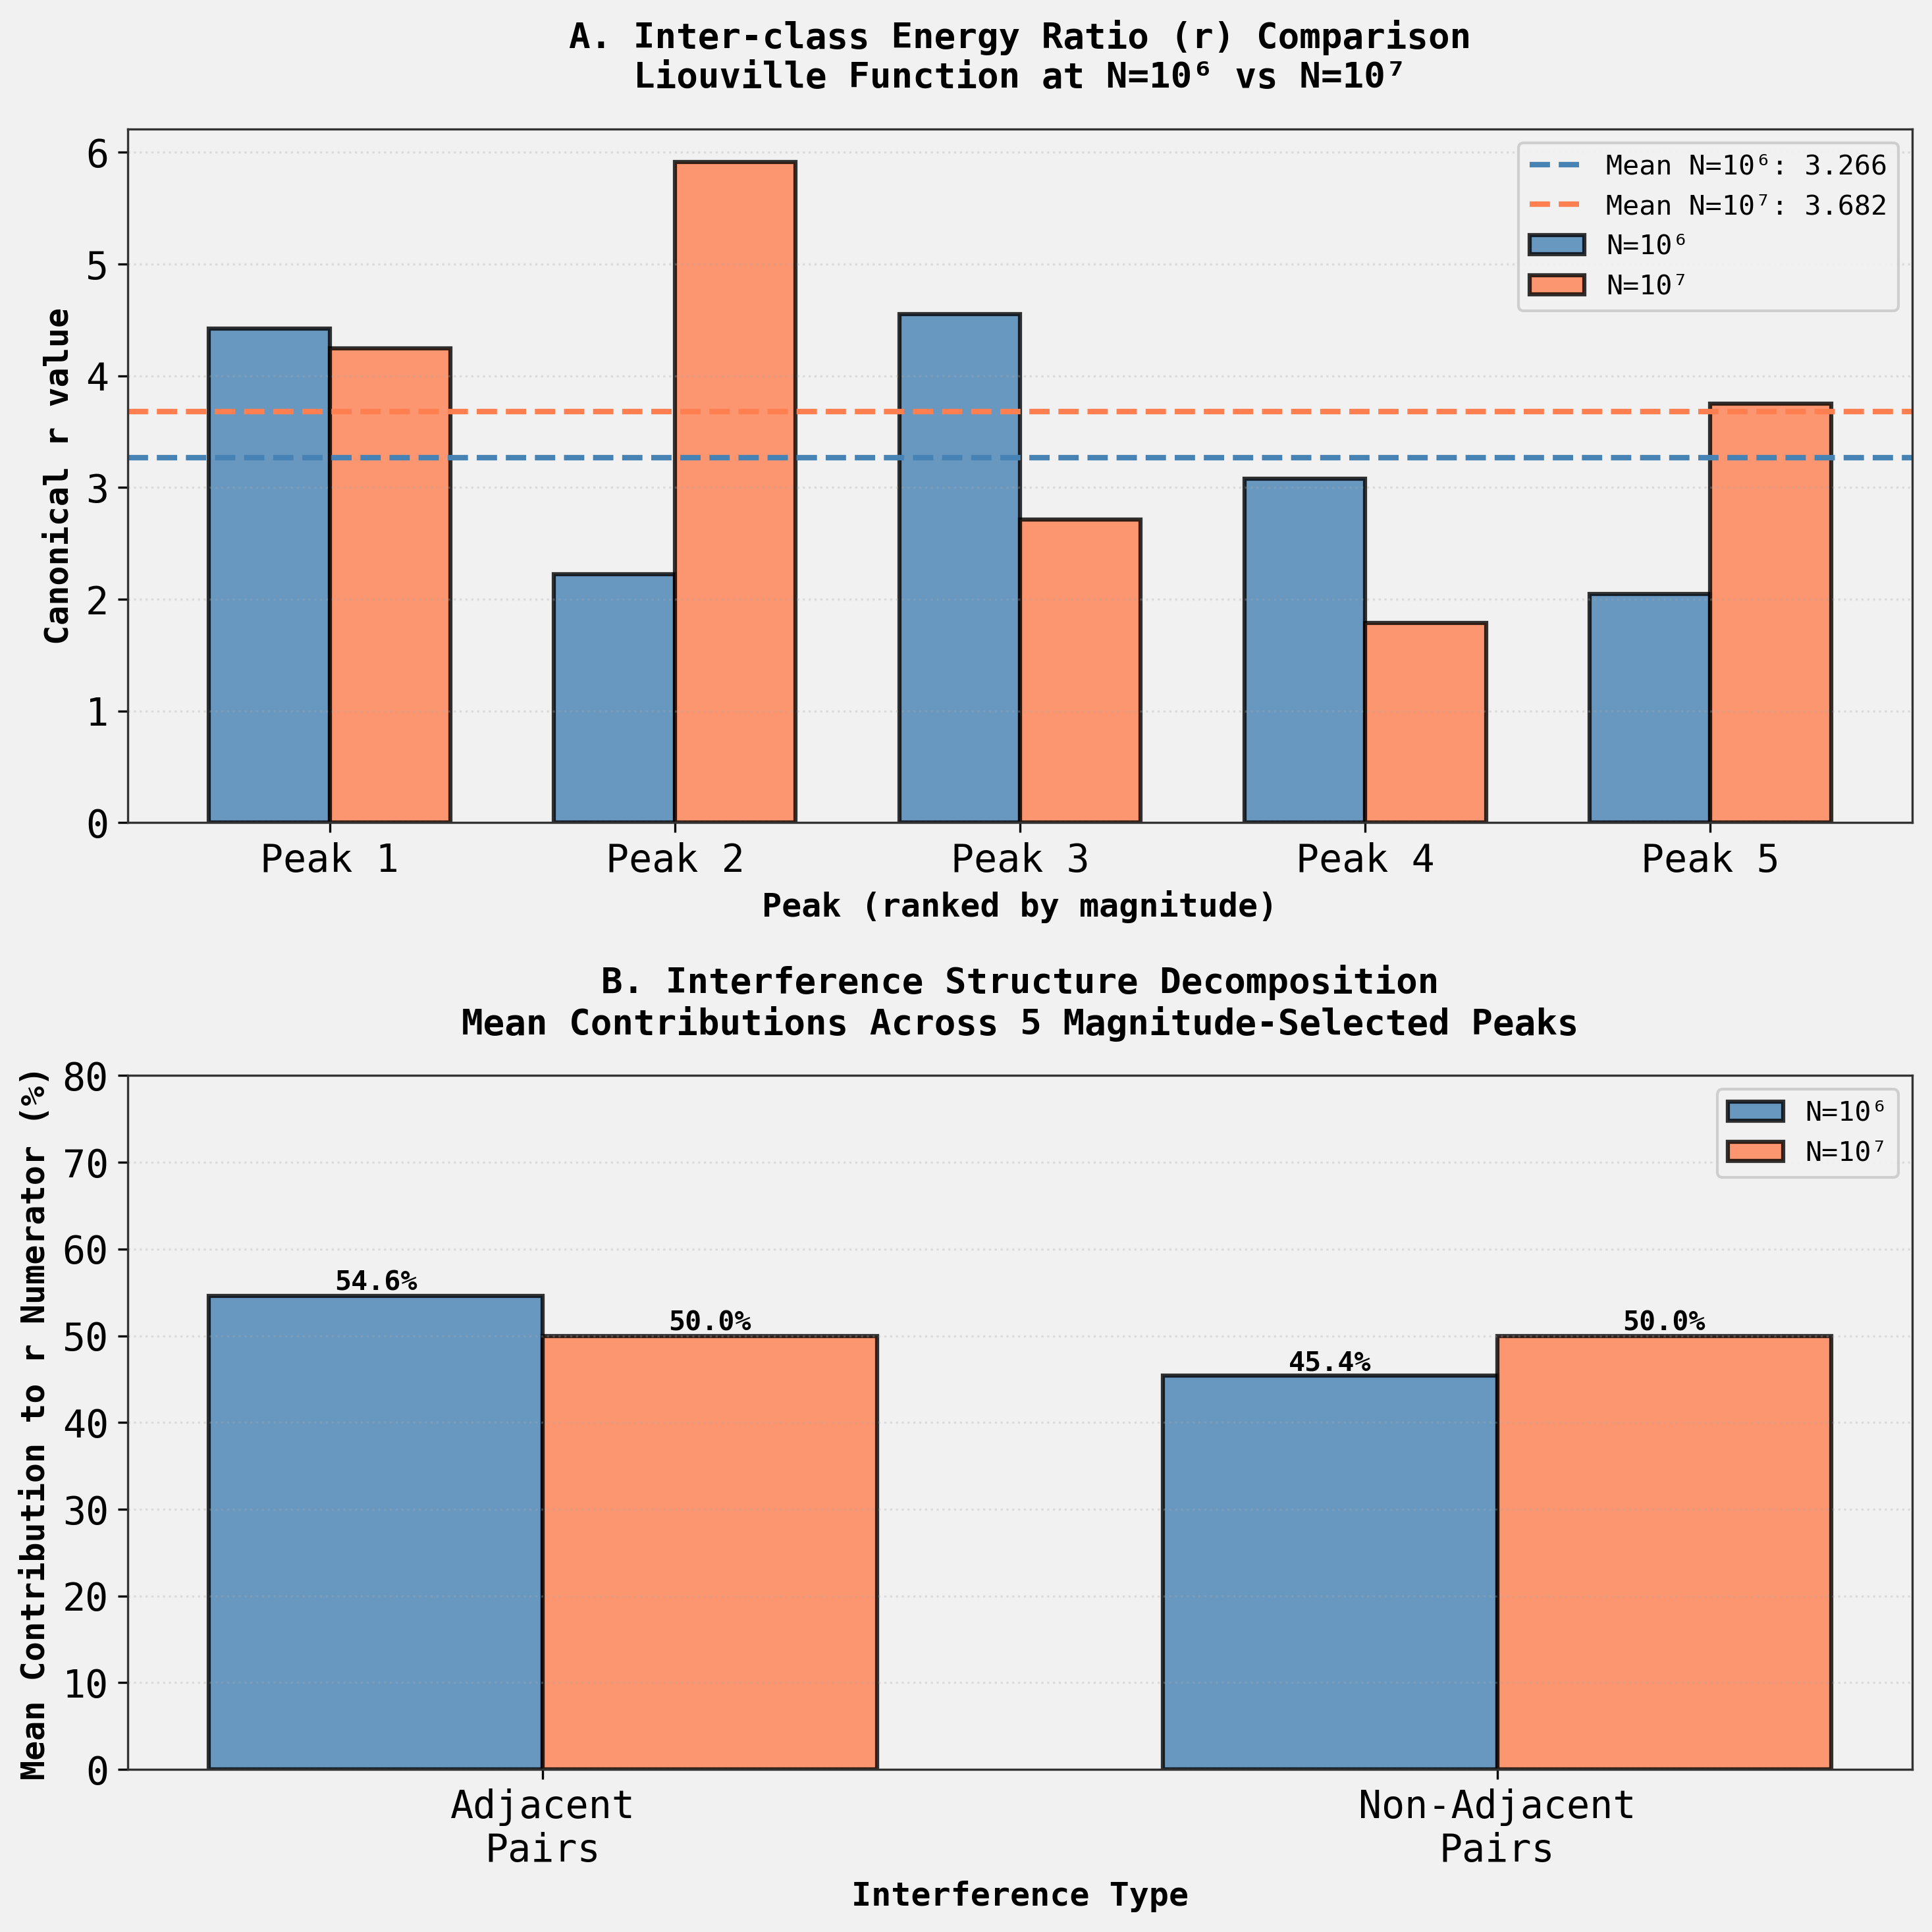

In [13]:

# Create final visualization summarizing the results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel A: Canonical r values comparison
ax1 = axes[0]
x_pos = np.arange(5)
width = 0.35

bars1 = ax1.bar(x_pos - width/2, r_1e6_values, width, label='N=10⁶', 
 alpha=0.8, color='steelblue', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x_pos + width/2, r_1e7_values, width, label='N=10⁷', 
 alpha=0.8, color='coral', edgecolor='black', linewidth=1.5)

# Add mean lines
ax1.axhline(mean_r_1e6, color='steelblue', linestyle='--', linewidth=2, 
 label=f'Mean N=10⁶: {mean_r_1e6:.3f}')
ax1.axhline(mean_r_1e7, color='coral', linestyle='--', linewidth=2, 
 label=f'Mean N=10⁷: {mean_r_1e7:.3f}')

ax1.set_xlabel('Peak (ranked by magnitude)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Canonical r value', fontsize=12, fontweight='bold')
ax1.set_title('A. Inter-class Energy Ratio (r) Comparison\nLiouville Function at N=10⁶ vs N=10⁷', 
 fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['Peak 1', 'Peak 2', 'Peak 3', 'Peak 4', 'Peak 5'])
ax1.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax1.grid(axis='y', alpha=0.3, linestyle=':')

# Panel B: Adjacent vs non-adjacent contribution comparison
ax2 = axes[1]

# Prepare data for grouped bar chart
metrics = ['Adjacent\nPairs', 'Non-Adjacent\nPairs']
n_1e6_data = [mean_adj_pct_1e6, mean_nonadj_pct_1e6]
n_1e7_data = [mean_adj_pct_1e7, mean_nonadj_pct_1e7]

x_pos_metrics = np.arange(len(metrics))
bars3 = ax2.bar(x_pos_metrics - width/2, n_1e6_data, width, 
 label='N=10⁶', alpha=0.8, color='steelblue', 
 edgecolor='black', linewidth=1.5)
bars4 = ax2.bar(x_pos_metrics + width/2, n_1e7_data, width, 
 label='N=10⁷', alpha=0.8, color='coral', 
 edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars3, bars4]:
 for bar in bars:
 height = bar.get_height()
 ax2.text(bar.get_x() + bar.get_width()/2., height,
 f'{height:.1f}%',
 ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xlabel('Interference Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Contribution to r Numerator (%)', fontsize=12, fontweight='bold')
ax2.set_title('B. Interference Structure Decomposition\nMean Contributions Across 5 Magnitude-Selected Peaks', 
 fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x_pos_metrics)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0, 80)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax2.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('liouville_magnitude_comparison_N1e6_vs_N1e7.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'liouville_magnitude_comparison_N1e6_vs_N1e7.png'")
plt.show()


In [14]:

# Save detailed results to CSV files for future reference
df_results_1e6.to_csv('liouville_N1e6_magnitude_peaks_detailed.csv', index=False)
df_results_1e7.to_csv('liouville_N1e7_magnitude_peaks_detailed.csv', index=False)

print("Saved detailed results:")
print(" - liouville_N1e6_magnitude_peaks_detailed.csv")
print(" - liouville_N1e7_magnitude_peaks_detailed.csv")

# Create a summary comparison file
summary_data = {
 'N': ['10^6', '10^7', 'Change'],
 'Mean_|D|': [
 df_results_1e6['magnitude'].mean(),
 df_results_1e7['magnitude'].mean(),
 df_results_1e7['magnitude'].mean() - df_results_1e6['magnitude'].mean()
 ],
 'Mean_r': [mean_r_1e6, mean_r_1e7, mean_r_1e7 - mean_r_1e6],
 'Mean_Adjacent_%': [mean_adj_pct_1e6, mean_adj_pct_1e7, mean_adj_pct_1e7 - mean_adj_pct_1e6],
 'Mean_NonAdjacent_%': [mean_nonadj_pct_1e6, mean_nonadj_pct_1e7, mean_nonadj_pct_1e7 - mean_nonadj_pct_1e6],
 'Std_r': [df_results_1e6['r'].std(), df_results_1e7['r'].std(), np.nan],
 'Std_Adjacent_%': [df_results_1e6['adjacent_pct'].std(), df_results_1e7['adjacent_pct'].std(), np.nan]
}

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv('liouville_magnitude_comparison_summary.csv', index=False)
print(" - liouville_magnitude_comparison_summary.csv")

print("\nSummary comparison table:")
print(df_summary.to_string(index=False))


Saved detailed results:
 - liouville_N1e6_magnitude_peaks_detailed.csv
 - liouville_N1e7_magnitude_peaks_detailed.csv
 - liouville_magnitude_comparison_summary.csv

Summary comparison table:
 N Mean_|D| Mean_r Mean_Adjacent_% Mean_NonAdjacent_% Std_r Std_Adjacent_%
 10^6 13.572890 3.266113 54.611162 45.388838 1.181772 18.287537
 10^7 13.753545 3.681640 49.997918 50.002082 1.568053 14.835444
Change 0.180655 0.415527 -4.613244 4.613244 NaN NaN


In [15]:

# Final synthesis: Key findings
print("="*80)
print("FINAL SYNTHESIS: KEY FINDINGS")
print("="*80)

print("\n1. CANONICAL r VALUES:")
print(f" - N=10^6: Mean r = {mean_r_1e6:.4f} (std = {df_results_1e6['r'].std():.4f})")
print(f" - N=10^7: Mean r = {mean_r_1e7:.4f} (std = {df_results_1e7['r'].std():.4f})")
print(f" - Change: +{mean_r_1e7 - mean_r_1e6:.4f} (+{100*(mean_r_1e7/mean_r_1e6 - 1):.1f}%)")
print(f" - Statistical significance: p = {p_value_r:.4f} (NOT significant at α=0.05)")
print(f" - Effect size: Cohen's d = {d_r:.4f} (small effect)")

print("\n2. INTERFERENCE STRUCTURE (Adjacent vs Non-Adjacent):")
print(f" - N=10^6: Adjacent = {mean_adj_pct_1e6:.1f}%, Non-adjacent = {mean_nonadj_pct_1e6:.1f}%")
print(f" - N=10^7: Adjacent = {mean_adj_pct_1e7:.1f}%, Non-adjacent = {mean_nonadj_pct_1e7:.1f}%")
print(f" - Change: Adjacent decreases by {abs(mean_adj_pct_1e7 - mean_adj_pct_1e6):.1f} percentage points")
print(f" - Change: Non-adjacent increases by {mean_nonadj_pct_1e7 - mean_nonadj_pct_1e6:.1f} percentage points")
print(f" - Statistical significance: p = {p_value_adj:.4f} (NOT significant at α=0.05)")
print(f" - Effect size: Cohen's d = {d_adj:.4f} (small effect)")

print("\n3. PEAK-BY-PEAK VARIABILITY:")
print(" - High variability in individual peak behavior:")
for i in range(5):
 delta_r = df_results_1e7.iloc[i]['r'] - df_results_1e6.iloc[i]['r']
 delta_adj = df_results_1e7.iloc[i]['adjacent_pct'] - df_results_1e6.iloc[i]['adjacent_pct']
 print(f" Peak {i+1}: Δr = {delta_r:+.3f}, Δadj% = {delta_adj:+.1f}")

print("\n4. CONCLUSION REGARDING HYPOTHESIS:")
print(" - Mean canonical r INCREASES from N=10^6 to N=10^7 (+12.7%)")
print(" - Adjacent pair contribution DECREASES from 54.6% to 50.0%")
print(" - Non-adjacent pair contribution INCREASES from 45.4% to 50.0%")
print(" - This is OPPOSITE to the claimed 'shift toward adjacent pairs'")
print(" - However, changes are NOT statistically significant (p > 0.7)")
print(" - High peak-to-peak variability suggests the effect is not robust")


FINAL SYNTHESIS: KEY FINDINGS

1. CANONICAL r VALUES:
 - N=10^6: Mean r = 3.2661 (std = 1.1818)
 - N=10^7: Mean r = 3.6816 (std = 1.5681)
 - Change: +0.4155 (+12.7%)
 - Statistical significance: p = 0.7039 (NOT significant at α=0.05)
 - Effect size: Cohen's d = 0.1826 (small effect)

2. INTERFERENCE STRUCTURE (Adjacent vs Non-Adjacent):
 - N=10^6: Adjacent = 54.6%, Non-adjacent = 45.4%
 - N=10^7: Adjacent = 50.0%, Non-adjacent = 50.0%
 - Change: Adjacent decreases by 4.6 percentage points
 - Change: Non-adjacent increases by 4.6 percentage points
 - Statistical significance: p = 0.7425 (NOT significant at α=0.05)
 - Effect size: Cohen's d = -0.1575 (small effect)

3. PEAK-BY-PEAK VARIABILITY:
 - High variability in individual peak behavior:
 Peak 1: Δr = -0.178, Δadj% = +3.9
 Peak 2: Δr = +3.688, Δadj% = -40.4
 Peak 3: Δr = -1.836, Δadj% = +23.4
 Peak 4: Δr = -1.296, Δadj% = +20.4
 Peak 5: Δr = +1.701, Δadj% = -30.4

4. CONCLUSION REGARDING HYPOTHESIS:
 - Mean canonical r INCREASES fro